## Регрессия, длительность госпитализации

### Задание.

В файле *cardiovascular_hospital_los.csv* представлены биомедицинские данные госпитализированных пациентов с сердечно-сосудистыми заболеваниями. Необходимо предсказать длительность госпитализации (целевая переменная *'los_days'*) на основании представленных признаков.

Выполните следующие задания:

1) Проведите полный цикл предварительной обработки данных.  
- Обратите внимание, поскольку задача построения регрессионной модели - это задача обучения с учителем, то данные должны быть разделены на обучающую и тестовую выборки. Поэтому будьте внимательны и применяйте шаги предварительной обработки в правильном порядке.

2) Сформируйте три подмножества признаков: subset1 (все признаки), subset2 (статистически значимые признаки для модели линейной регрессии), subset3 (признаки, статистически значимо коррелирующие с целевой переменной).  
- Обратите внимание, что подмножества subset2 и subset3 должны быть получены на основе обучающей выборки, а не всего набора данных.  
- Также обратите внимание, что при построении subset3 для категориальных переменных нельзя напрямую использовать тесты на корреляцию. Вопрос в случае категориальных переменных формулируется как "Существуют ли отличия в длительности госпитализации между категориями?", поэтому необходимо подобрать нужный статистический тест. Также, например, если некоторый категориальный признак С имеет более двух категорий, то для статистического тестирования необходимо рассматривать непосредственно этот признак со всеми его категориями, а не отдельно каждый столбец из его One Hot Encoding версии. В случае, если статистическая значимость будет установлена, то в subset3 включаем уже One Hot Encoding столбцы этого признака.
- Наблюдаются ли отличия между полученными subset2 и subset3? Какие признаки есть в одном подмножестве, но нет в другом?

3) Примените модель линейной регрессии LinearRegression к трем наборам признаков: subset1, subset2 и subset3. Вычислите следующие метрики качества на тестовой выборке: скорректированный коэффициент детерминации, RMSE, MAE. Наблюдается ли улучшение качества предсказаний при рассмотрении subset2 и subset3 по сравнению с subset1?

4) Примените модель ElasticNet к набору признаков subset1. Для этого выполните подбор двух гиперпараметров модели с помощью кросс-валидации по 5 блокам. Вычислите те же метрики качества результирующей оптимальной модели (с подобранными оптимальными гиперпараметрыми) на тестовой выборке. Наблюдается ли улучшение качества по сравнению с моделями из предыдущего пункта?

## 1) Предварительная обработка данных

1) Проведите полный цикл предварительной обработки данных.
- Обратите внимание, поскольку задача построения регрессионной модели - это задача обучения с учителем, то данные должны быть разделены на обучающую и тестовую выборки. Поэтому будьте внимательны и применяйте шаги предварительной обработки в правильном порядке.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# 1) Данные и целевая переменная

df = pd.read_csv(
    "cardiovascular_hospital_los.csv",
    sep="\t"
)

# Временно увеличиваем количество отображаемых столбцов
pd.set_option('display.max_columns', None)  # None = показывать все столбцы
pd.set_option('display.expand_frame_repr', False)  # Не переносить таблицу на несколько строк

# Теперь head() покажет все столбцы
df.head()



,age,gender,smoking,alcohol_last_week,sbp,dbp,heart_rate,severity_score,creatinine,troponin,ck_mb,nt_probnp,crp,wbc,hb,platelets,ldl,hdl,glucose,tnfa_expression,il6_expression,mmp9_expression,vegf_expression,pcsk9_mutation,los_days
0,70.0,Male,1,0,113,92,123,119,3.695930,3.522529,56.0,10000.000000,21.043341,9.169412,100.900000,272.0,4.230000,1.260000,4.4,2.72,34.99,41.03,55.11,Wild,20.0
1,63.0,Male,0,0,119,74,70,125,1.590031,0.596930,27.6,1143.052113,4.400000,12.200000,133.900000,346.0,1.851611,1.030000,8.4,9.44,8.72,9.16,320.70,Homozygous,12.0
2,72.0,Male,1,1,220,88,51,134,3.301389,1.211761,97.2,666.803295,11.593157,7.296688,139.100000,270.0,3.060000,0.704008,5.9,11.49,4.66,11.25,41.92,Wild,17.0
3,83.0,Female,0,1,178,57,76,121,3.737128,15.982889,19.7,4254.497860,6.400000,10.000000,123.033675,307.0,3.010000,2.500000,6.3,13.21,17.56,39.74,152.04,Wild,22.0
4,62.0,Male,0,0,106,94,45,124,5.000000,0.728508,7.1,8945.582372,7.300000,4.400000,124.900000,327.0,2.770000,0.730000,7.2,9.77,4.04,43.70,93.92,Wild,15.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 743 entries, 0 to 742
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                742 non-null    float64
 1   gender             742 non-null    str    
 2   smoking            743 non-null    int64  
 3   alcohol_last_week  743 non-null    int64  
 4   sbp                743 non-null    int64  
 5   dbp                743 non-null    int64  
 6   heart_rate         743 non-null    int64  
 7   severity_score     743 non-null    int64  
 8   creatinine         743 non-null    float64
 9   troponin           742 non-null    float64
 10  ck_mb              743 non-null    float64
 11  nt_probnp          743 non-null    float64
 12  crp                743 non-null    float64
 13  wbc                743 non-null    float64
 14  hb                 743 non-null    float64
 15  platelets          743 non-null    float64
 16  ldl                743 non-null    fl

Размер до очистки: 592
Размер после очистки: 303
Удалено выбросов: 289
Пропуски в los_days (строки удалены): 2
Train: 303, Test: 149
Категориальные признаки: ['gender', 'smoking', 'alcohol_last_week', 'pcsk9_mutation']
Числовые признаки: ['age', 'sbp', 'dbp', 'heart_rate', 'severity_score', 'creatinine', 'troponin', 'ck_mb', 'nt_probnp', 'crp', 'wbc', 'hb', 'platelets', 'ldl', 'hdl', 'glucose', 'tnfa_expression', 'il6_expression', 'mmp9_expression', 'vegf_expression']
Число признаков после one-hot: 26


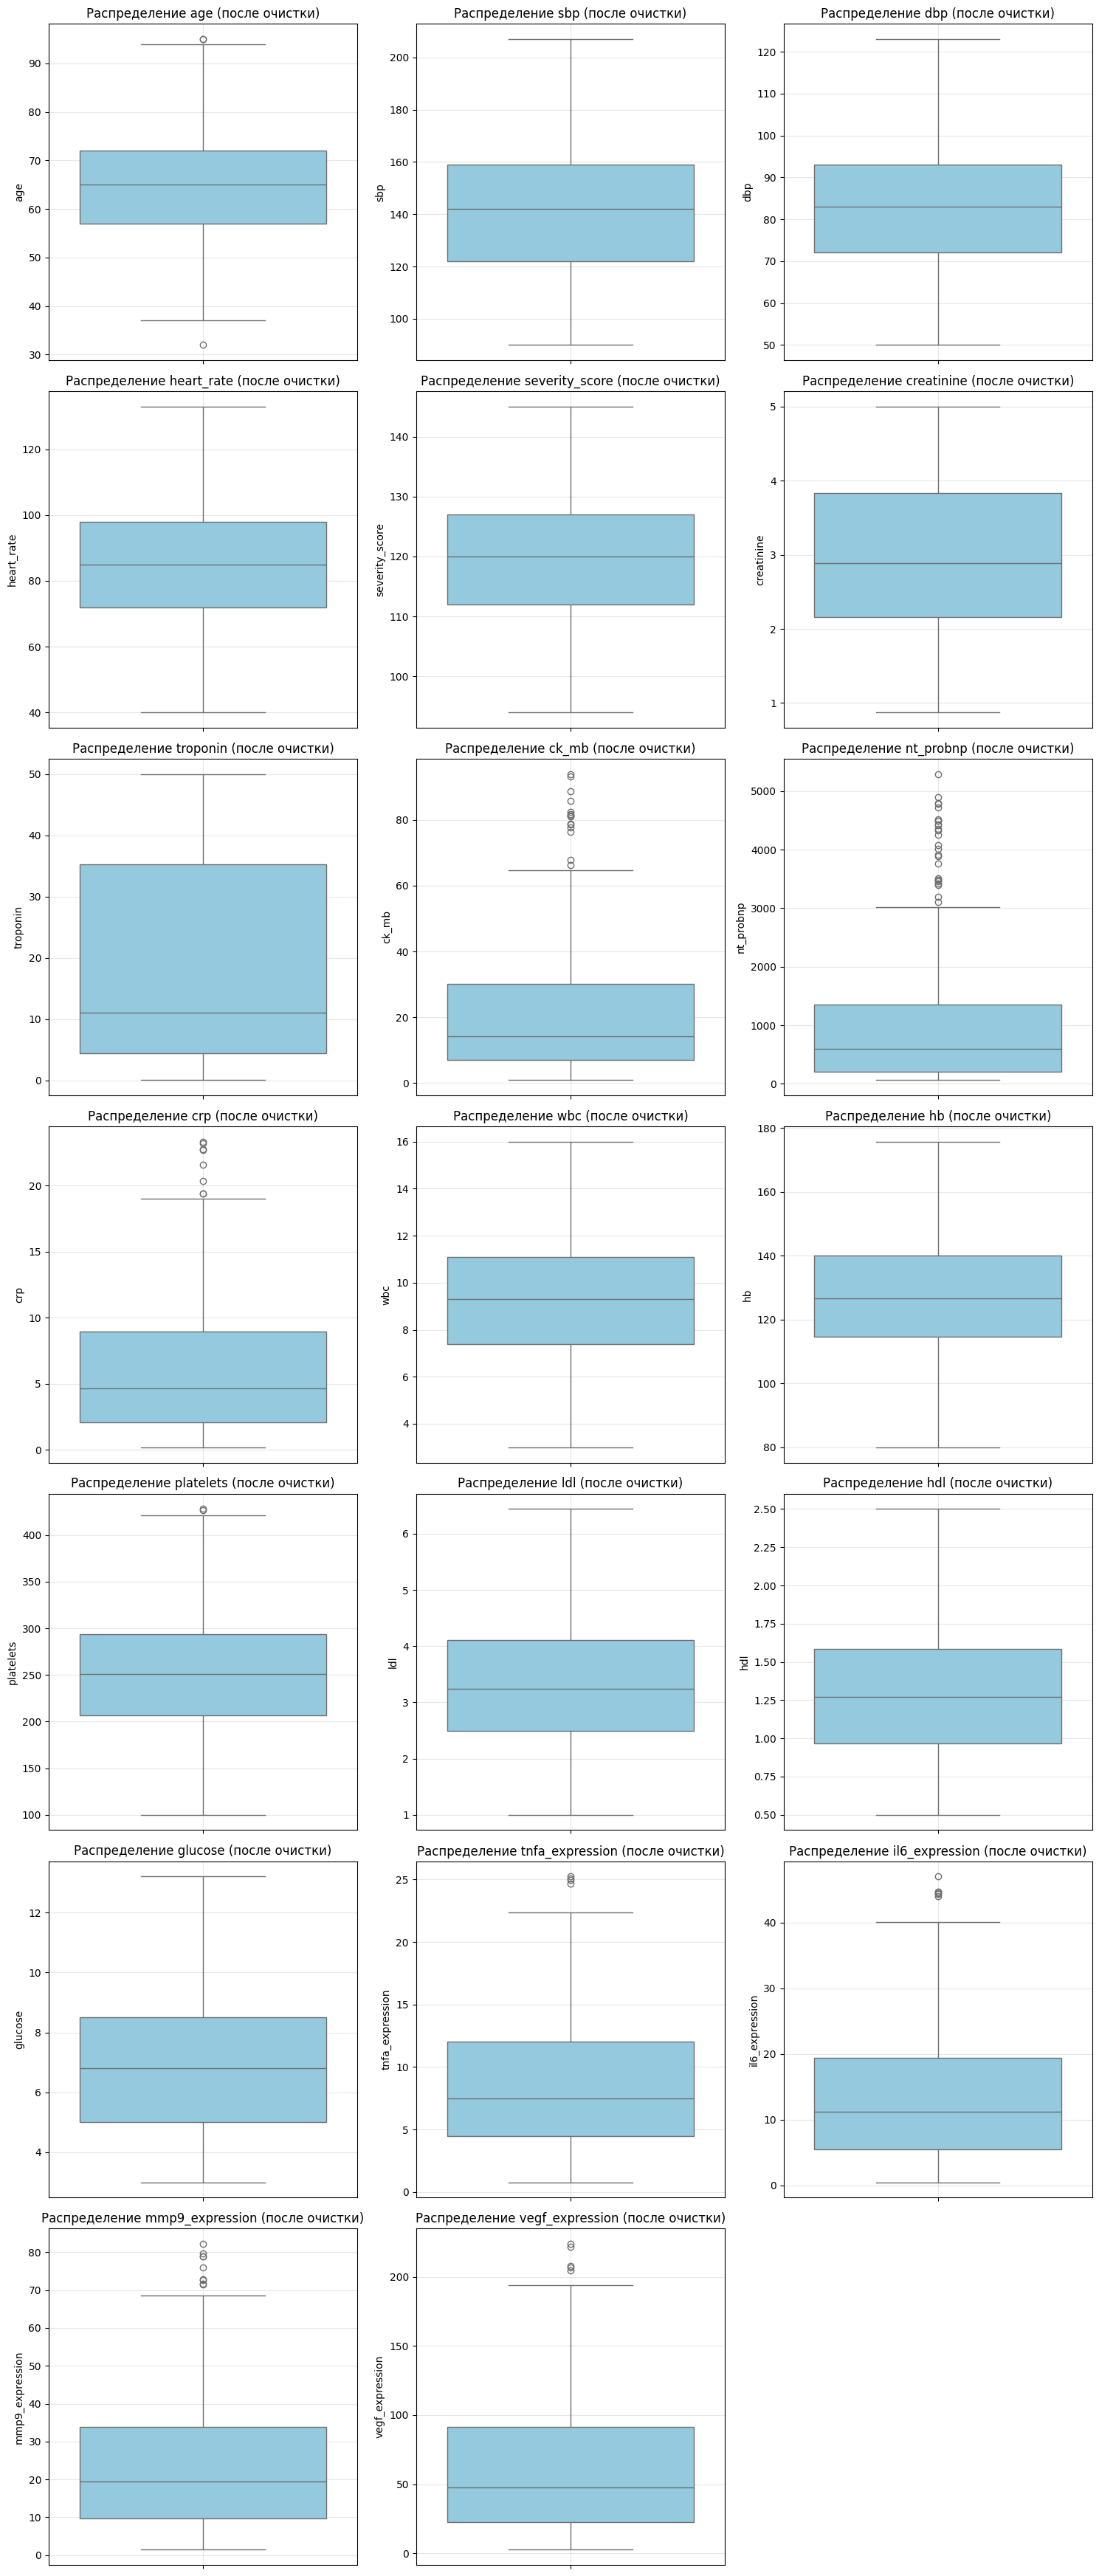

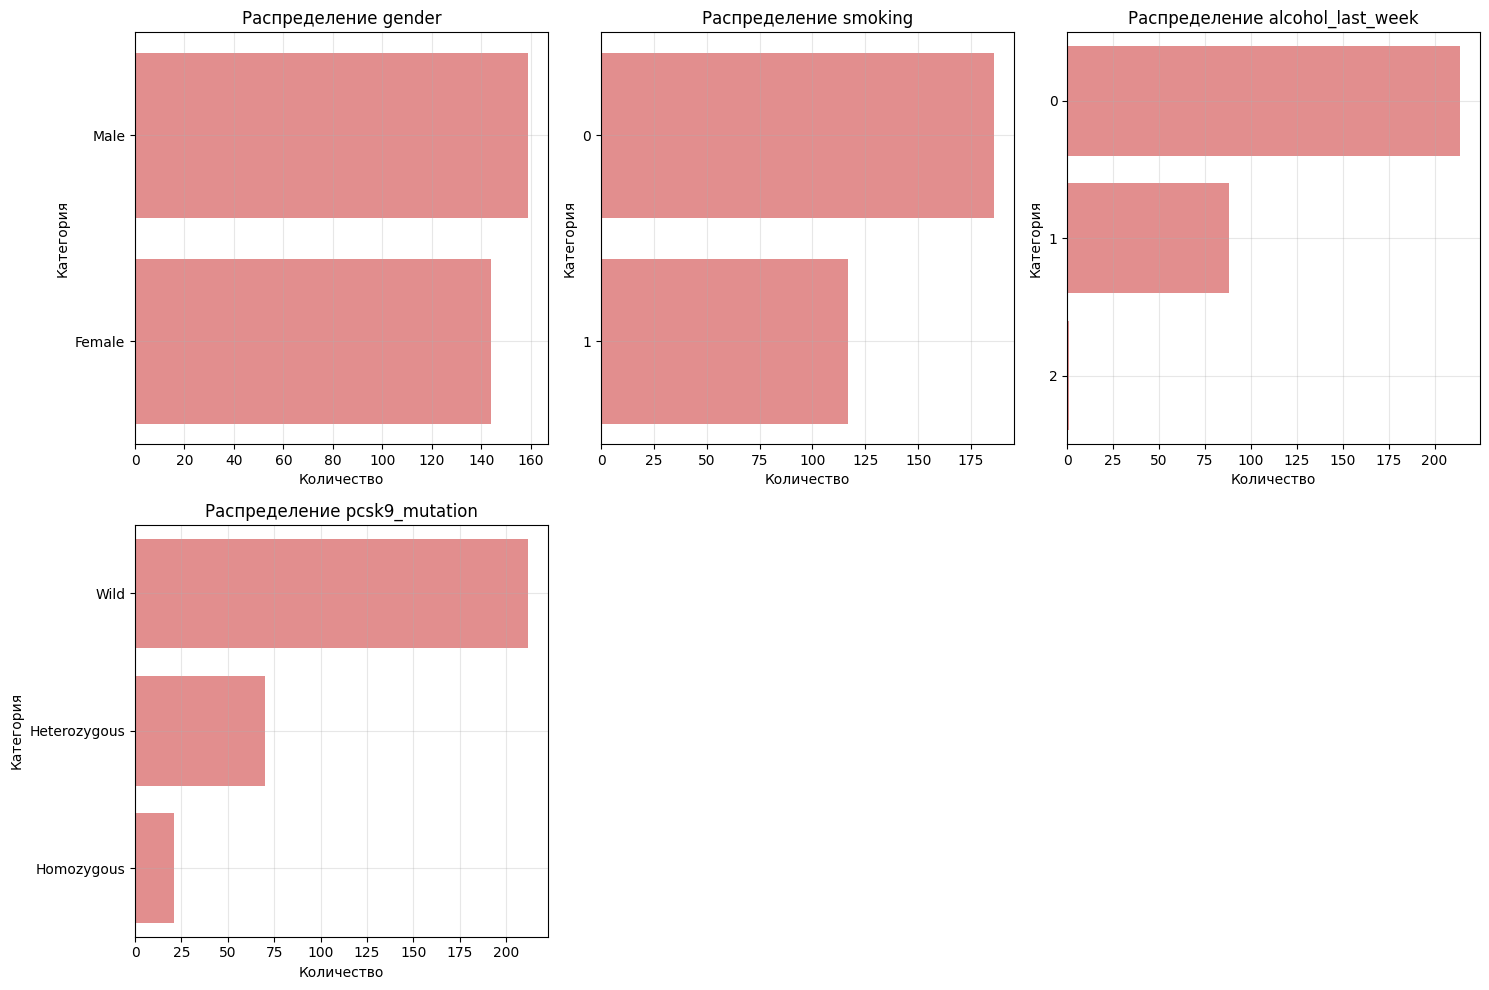

In [3]:
# Сначала получаем все переменные из предыдущих шагов
# Разделение на train/test и обработка пропусков

# Удаляем строки с пропусками в целевой переменной
mask_y = df['los_days'].notna()
df_clean = df[mask_y]

X = df_clean.drop('los_days', axis=1)
y = df_clean['los_days']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Определяем числовые и категориальные признаки
# Все категориальные признаки задаем вручную.
cat_cols = ['gender', 'smoking', 'alcohol_last_week', 'pcsk9_mutation']
num_cols = [c for c in X_train.columns if c not in cat_cols]

# Импутация числовых признаков
num_imputer = SimpleImputer(strategy='median')
X_train_num = num_imputer.fit_transform(X_train[num_cols])
X_test_num = num_imputer.transform(X_test[num_cols])

# Импутация категориальных признаков
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train_cat = cat_imputer.fit_transform(X_train[cat_cols])
X_test_cat = cat_imputer.transform(X_test[cat_cols])

# 4) Очистка от выбросов (метод IQR)
def remove_outliers_iqr(data, columns):
    """Удаляет выбросы методом межквартильного размаха"""
    data_clean = data.copy()
    outlier_mask = np.ones(len(data_clean), dtype=bool)
    
    for col in columns:
        if col in data_clean.columns:
            Q1 = data_clean[col].quantile(0.25)
            Q3 = data_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            col_mask = (data_clean[col] >= lower_bound) & (data_clean[col] <= upper_bound)
            outlier_mask &= col_mask
    
    return data_clean[outlier_mask], outlier_mask

# Применяем очистку к обучающим данным
X_train_df = pd.DataFrame(X_train_num, columns=num_cols)
X_train_clean, outlier_mask = remove_outliers_iqr(X_train_df, num_cols)

# Удаляем соответствующие строки из y_train и X_train_cat
# Используем reset_index() чтобы совпадали индексы
y_train_clean = y_train.reset_index(drop=True).iloc[outlier_mask]
X_train_cat_clean = X_train_cat[outlier_mask]

# Обновляем train-данные после очистки выбросов
X_train_num = X_train_clean.values
y_train = y_train_clean.reset_index(drop=True)

print(f"Размер до очистки: {X_train.shape[0]}")
print(f"Размер после очистки: {X_train_clean.shape[0]}")
print(f"Удалено выбросов: {X_train.shape[0] - X_train_clean.shape[0]}")

# 5) One-hot encoding для категориальных
onehot = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)

# Кодируем категориальные признаки
X_train_cat_ohe = onehot.fit_transform(X_train_cat_clean)
X_test_cat_ohe = onehot.transform(X_test_cat)
cat_feature_names = onehot.get_feature_names_out(cat_cols)

# 6) Финальная матрица признаков (subset1 = все)
X_train_full = np.hstack([X_train_num, X_train_cat_ohe])
X_test_full = np.hstack([X_test_num, X_test_cat_ohe])

feature_names_full = np.array(num_cols + list(cat_feature_names), dtype=object)

print("Пропуски в los_days (строки удалены):", int((~mask_y).sum()))
print(f"Train: {X_train_full.shape[0]}, Test: {X_test_full.shape[0]}")
print("Категориальные признаки:", cat_cols)
print("Числовые признаки:", num_cols)
print("Число признаков после one-hot:", X_train_full.shape[1])


# Графики для первичного анализа: боксплоты для числовых, столбчатые диаграммы для категориальных

# Боксплоты для всех числовых признаков
if num_cols:
    cols = min(3, len(num_cols))  # Максимум 3 колонки
    rows = (len(num_cols) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    axes = np.array(axes).reshape(-1)
    
    for i, col in enumerate(num_cols):
        ax = axes[i]
        sns.boxplot(y=X_train_clean[col], ax=ax, color="skyblue")
        ax.set_title(f'Распределение {col} (после очистки)')
        ax.set_ylabel(col)
        ax.grid(True, alpha=0.3)
    
    # Скрываем лишние subplot'ы
    for i in range(len(num_cols), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Столбчатые диаграммы для всех категориальных признаков
if cat_cols:
    cols = min(3, len(cat_cols))  # Максимум 3 колонки
    rows = (len(cat_cols) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    axes = np.array(axes).reshape(-1)
    
    for i, col in enumerate(cat_cols):
        ax = axes[i]
        vc = pd.Series(X_train_cat_clean[:, i]).value_counts(dropna=False).head(10)
        sns.barplot(x=vc.values, y=vc.index.astype(str), ax=ax, color="lightcoral")
        ax.set_title(f'Распределение {col}')
        ax.set_xlabel("Количество")
        ax.set_ylabel("Категория")
        ax.grid(True, alpha=0.3)
    
    # Скрываем лишние subplot'ы
    for i in range(len(cat_cols), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

По данным `cardiovascular_hospital_los.csv`:

- Пропуски в `los_days` удалены: 2 строки.
- Train/test разделение: `592 / 149`.
- Категориальные признаки (по типу/кардинальности): `['gender', 'smoking', 'alcohol_last_week', 'pcsk9_mutation']`.
- Числовые признаки: остальные 20 столбцов.
- После one-hot кодирования (с `drop='first'`) получилось `26` числовых признаков для моделей.

Все шаги препроцессинга (imputation, one-hot) подгоняются только на обучающей выборке, затем применяются к тестовой.

## 2) Подмножества признаков

2) Сформируйте три подмножества признаков: `subset1` (все признаки), `subset2` (статистически значимые признаки для модели линейной регрессии), `subset3` (признаки, статистически значимо коррелирующие с целевой переменной).

- Обратите внимание, что подмножества `subset2` и `subset3` должны быть получены на основе обучающей выборки, а не всего набора данных.
- Также обратите внимание, что при построении `subset3` для категориальных переменных нельзя напрямую использовать тесты на корреляцию. Вопрос в случае категориальных переменных формулируется как "Существуют ли отличия в длительности госпитализации между категориями?", поэтому необходимо подобрать нужный статистический тест. Также, например, если некоторый категориальный признак `C` имеет более двух категорий, то для статистического тестирования необходимо рассматривать непосредственно этот признак со всеми его категориями, а не отдельно каждый столбец из его One Hot Encoding версии. В случае, если статистическая значимость будет установлена, то в `subset3` включаем уже One Hot Encoding столбцы этого признака.

In [4]:
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

alpha = 0.05

# subset1: все признаки после preprocessing/one-hot
subset1_idx = np.arange(X_train_full.shape[1])

# Проверка на согласованность размеров, чтобы избежать скрытых ошибок.
if len(X_train_full) != len(y_train):
    raise ValueError(
        f"Размерности не совпадают: X_train_full={len(X_train_full)}, y_train={len(y_train)}. "
        "Перезапустите ячейку предобработки (train/test + очистка выбросов)."
    )

#  subset2: значимые признаки по p-value в OLS 
X_train_df_full = pd.DataFrame(X_train_full, columns=feature_names_full)
X_train_sm = sm.add_constant(X_train_df_full, has_constant="add")
ols_model = sm.OLS(y_train.values, X_train_sm).fit()

# Исключаем intercept и оставляем только статистически значимые коэффициенты.
coef_pvalues = ols_model.pvalues.drop(labels="const", errors="ignore")
coef_pvalues = coef_pvalues[np.isfinite(coef_pvalues)]
subset2_encoded = coef_pvalues[coef_pvalues < alpha].index.tolist()
subset2_idx = np.array([X_train_df_full.columns.get_loc(c) for c in subset2_encoded], dtype=int)


# Вспомогательная функция: перевод one-hot признака обратно к исходному полю.
def parent_feature(encoded_name):
    if encoded_name in num_cols:
        return encoded_name
    for c in cat_cols:
        if str(encoded_name).startswith(c + "_"):
            return c
    return str(encoded_name)

subset2_original = sorted({parent_feature(n) for n in subset2_encoded})


# subset3: связь с целевой переменной (непараметрические тесты)
# Числовые признаки: тест Спирмена (ранговая корреляция, не требует нормальности).
subset3_num = []
for i, col in enumerate(num_cols):
    # Spearman вместо Pearson - более устойчив к выбросам и не требует нормальности
    corr, p = stats.spearmanr(X_train_num[:, i], y_train.values)
    if np.isfinite(p) and p < alpha:
        subset3_num.append(col)

# Категориальные признаки: тест Краскела-Уоллиса (непараметрическая альтернатива ANOVA)
subset3_cat = []
for j, col in enumerate(cat_cols):
    x = pd.Series(X_train_cat_clean[:, j], name="cat").astype("category")
    if x.nunique(dropna=True) < 2:
        continue
    
    # Собираем значения y для каждой категории в список групп
    groups = [y_train.values[x == cat] for cat in x.cat.categories]
    # Удаляем пустые группы (на случай, если категория есть в x, но нет данных в y)
    groups = [g for g in groups if len(g) > 0]
    
    if len(groups) < 2:
        continue
    
    # Тест Краскела-Уоллиса - непараметрическая альтернатива однофакторному ANOVA
    # H0: все группы имеют одинаковое распределение (медианы равны)
    # H1: хотя бы одна группа отличается
    stat, p = stats.kruskal(*groups)
    
    if np.isfinite(p) and p < alpha:
        subset3_cat.append(col)

subset3_original = sorted(subset3_num + subset3_cat)

# Соответствие original -> encoded для subset3.
subset3_idx = []

# Числовые признаки сохраняются один-в-один.
for i, col in enumerate(num_cols):
    if col in subset3_num:
        subset3_idx.append(i)

# Для категориальных добавляем все one-hot столбцы исходного признака.
for j, fname in enumerate(cat_feature_names):
    for c in cat_cols:
        if c in subset3_cat and str(fname).startswith(c + "_"):
            subset3_idx.append(len(num_cols) + j)
            break

subset3_idx = np.array(sorted(set(subset3_idx)), dtype=int)

print(f"subset1: p={len(subset1_idx)}")
print(f"subset2: p={len(subset2_idx)}")
print("subset2_original:", subset2_original)
print(f"subset3: p={len(subset3_idx)}")
print("subset3_original:", subset3_original)

only_in_subset2 = sorted(set(subset2_original) - set(subset3_original))
only_in_subset3 = sorted(set(subset3_original) - set(subset2_original))

print("Только в subset2:", only_in_subset2)
print("Только в subset3:", only_in_subset3)

subset1: p=26
subset2: p=16
subset2_original: ['age', 'alcohol_last_week', 'creatinine', 'crp', 'gender', 'hb', 'il6_expression', 'nt_probnp', 'pcsk9_mutation', 'sbp', 'severity_score', 'smoking', 'tnfa_expression', 'troponin', 'wbc']
subset3: p=8
subset3_original: ['age', 'creatinine', 'crp', 'sbp', 'severity_score', 'smoking', 'troponin', 'wbc']
Только в subset2: ['alcohol_last_week', 'gender', 'hb', 'il6_expression', 'nt_probnp', 'pcsk9_mutation', 'tnfa_expression']
Только в subset3: []


Результаты выбора подмножеств (α = 0.05):

- `subset1`: все признаки (после one-hot) — `p=26`.
- `subset2`: значимые коэффициенты линейной регрессии на train — `p=16`.
- `subset3`: признаки, статистически значимо связанные с `los_days` на train — `p=8`.

Отличия `subset2` и `subset3` (по исходным признакам, до one-hot):

- Только в `subset2`: `['alcohol_last_week', 'gender', 'hb', 'il6_expression', 'nt_probnp', 'pcsk9_mutation', 'tnfa_expression']`.
- Только в `subset3`: нет (то есть `subset3` содержится в `subset2`).

## 3) Линейная регрессия и метрики качества

3) Примените модель линейной регрессии `LinearRegression` к трем наборам признаков: `subset1`, `subset2` и `subset3`. Вычислите следующие метрики качества на тестовой выборке: скорректированный коэффициент детерминации, RMSE, MAE. Наблюдается ли улучшение качества предсказаний при рассмотрении `subset2` и `subset3` по сравнению с `subset1`?

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def adjusted_r2(y_true, y_pred, p):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


def eval_linear(idx):
    Xtr = X_train_full[:, idx]
    Xte = X_test_full[:, idx]

    model = LinearRegression()
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    adj = adjusted_r2(y_test.values, pred, p=len(idx))
    r2 = model.score(Xte, y_test)

    return {
        "p": int(len(idx)),
        "adj_r2_test": float(adj),
        "rmse": float(rmse),
        "mae": float(mae),
        "r2_test": float(r2),
    }

m1 = eval_linear(subset1_idx)
m2 = eval_linear(subset2_idx)
m3 = eval_linear(subset3_idx)

print("subset1:", m1)
print("subset2:", m2)
print("subset3:", m3)



subset1: {'p': 26, 'adj_r2_test': 0.7148836226384427, 'rmse': 1.652096999213857, 'mae': 1.3270577779210315, 'r2_test': 0.7649716348776352}
subset2: {'p': 16, 'adj_r2_test': 0.7698198914595877, 'rmse': 1.5440643849125852, 'mae': 1.2516018609074713, 'r2_test': 0.7947042275180107}
subset3: {'p': 8, 'adj_r2_test': 0.7393362041670326, 'rmse': 1.6921892054234227, 'mae': 1.361598206723607, 'r2_test': 0.7534261390769228}


## 4) ElasticNet и подбор гиперпараметров

4) Примените модель `ElasticNet` к набору признаков `subset1`. Для этого выполните подбор двух гиперпараметров модели с помощью кросс-валидации по 5 блокам. Вычислите те же метрики качества результирующей оптимальной модели (с подобранными оптимальными гиперпараметрыми) на тестовой выборке. Наблюдается ли улучшение качества по сравнению с моделями из предыдущего пункта?

In [6]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, KFold





param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1.0, 5.0, 10.0],
    "l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0],
}

enet = ElasticNet(max_iter=20000, random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    enet,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
)

gs.fit(X_train_full, y_train)

best = gs.best_estimator_
pred = best.predict(X_test_full)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
adj = adjusted_r2(y_test.values, pred, p=X_train_full.shape[1])

print("Лучшие параметры:", gs.best_params_)
print("Метрики на тесте:")
print({
    "adj_r2_test": float(adj),
    "rmse": float(rmse),
    "mae": float(mae),
    "r2_test": float(r2_score(y_test, pred)),
})


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.265e+02, tolerance: 3.018e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.348e+02, tolerance: 2.767e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted u

Лучшие параметры: {'alpha': 0.01, 'l1_ratio': 0.0}
Метрики на тесте:
{'adj_r2_test': 0.7192199298341628, 'rmse': 1.6394855728797362, 'mae': 1.319211658294178, 'r2_test': 0.76854615837681}


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.979e+02, tolerance: 3.528e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
